In [105]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
os.chdir('/Users/tsukasamiyaji/Desktop/Python3')
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from collections import Counter
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori as ap, association_rules as ap_rl
from icecream import ic
from joblib import Parallel,delayed
import shap

# Data Preparation

In [106]:
df = pd.read_csv('Fingerhut_modified.csv')
df = df.drop(['Unnamed: 0'],axis=1) 
pivot_table = pd.pivot_table(df, values='count', index='account_id', columns='ed_id',aggfunc='sum').fillna(0)
export_piv2 = pd.DataFrame(pivot_table)
export_piv2 = export_piv2.reset_index()
export_piv2.columns = ['account_id','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','26','27','28','29']
export_piv2.set_index('account_id',inplace=True)
export_piv2 = export_piv2.head(2000)
export_piv2.head()


,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,26,27,28,29
account_id,,,,,,,,,,,,,,,,,,,,,
-2147477843,4.0,1.0,0.0,9.0,5.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
-2147476504,3.0,1.0,1.0,18.0,8.0,7.0,1.0,1.0,0.0,0.0,...,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
-2147476077,0.0,1.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-2147475397,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
-2147473858,2.0,0.0,2.0,8.0,3.0,1.0,0.0,0.0,0.0,0.0,...,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [107]:
cond1 = export_piv2['7'] > 0
cond2 = export_piv2['18'] > 0
cond3 = export_piv2['29'] > 0 

condition_act  = [cond3, ~cond3]
choices_act    = [0,1]

condition_pur  = [(cond1 | cond2), (~cond1 | ~cond2)]
choices_pur     = [0,1]

condition_both  = [(cond1 | cond2) & (cond3), (cond1 | cond2) & ~(cond3), (~cond1 | ~cond2) & ~(cond3), (~cond1 | ~cond2) & (cond3)]
choices_both     = [0,1,2,3]



export_piv2["condition_purchase"] = np.select(condition_pur, choices_pur, default=np.nan)
export_piv2["condition_activation"] = np.select(condition_act, choices_act, default=np.nan)
export_piv2["condition_both"] = np.select(condition_both, choices_both, default=np.nan)
export_piv2.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,26,27,28,29,condition_purchase,condition_activation,condition_both
account_id,,,,,,,,,,,,,,,,,,,,,
-2147477843,4.0,1.0,0.0,9.0,5.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
-2147476504,3.0,1.0,1.0,18.0,8.0,7.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
-2147476077,0.0,1.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
-2147475397,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
-2147473858,2.0,0.0,2.0,8.0,3.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0


# XGBoost (Purchase)

In [108]:
ids_to_remove = ['7','18','28']
export_piv2_1 = export_piv2.drop(columns=ids_to_remove)


In [109]:
# Modify the dependent variable as per your requirements
X, y = export_piv2_1.drop(['condition_purchase', 'condition_activation', 'condition_both'], axis=1), export_piv2_1[['condition_purchase']]

# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

# Construct dmatrix for train model
dtrain_clf = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Train a model, modify the objective method as per your requirements
xgb_classifier = xgb.XGBClassifier(n_estimators=100, objective='binary:hinge', tree_method='hist', eta=0.1, max_depth=10, enable_categorical=True)
xgb_classifier.fit(X_train, y_train)

# make predictions for test data
y_pred = xgb_classifier.predict(X_test)
xgb_prediction = [round(value) for value in y_pred]

# Accuracy rate, modify the dependent variable as per your requirements
print(f"Accuracy rate: {sum(xgb_prediction == y_test['condition_purchase'])/len(xgb_prediction)}")

# Sample numeric vector
numeric_vector = xgb_prediction

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")

# Sample numeric vector, modify the objective method as per your requirements
numeric_vector = y_test['condition_purchase']

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")


Accuracy rate: 0.9616666666666667
Number of Each Element:
0: 114
1: 486
Number of Each Element:
0.0: 121
1.0: 479


In [110]:
# Use SHAP to explain the output of the model
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test)


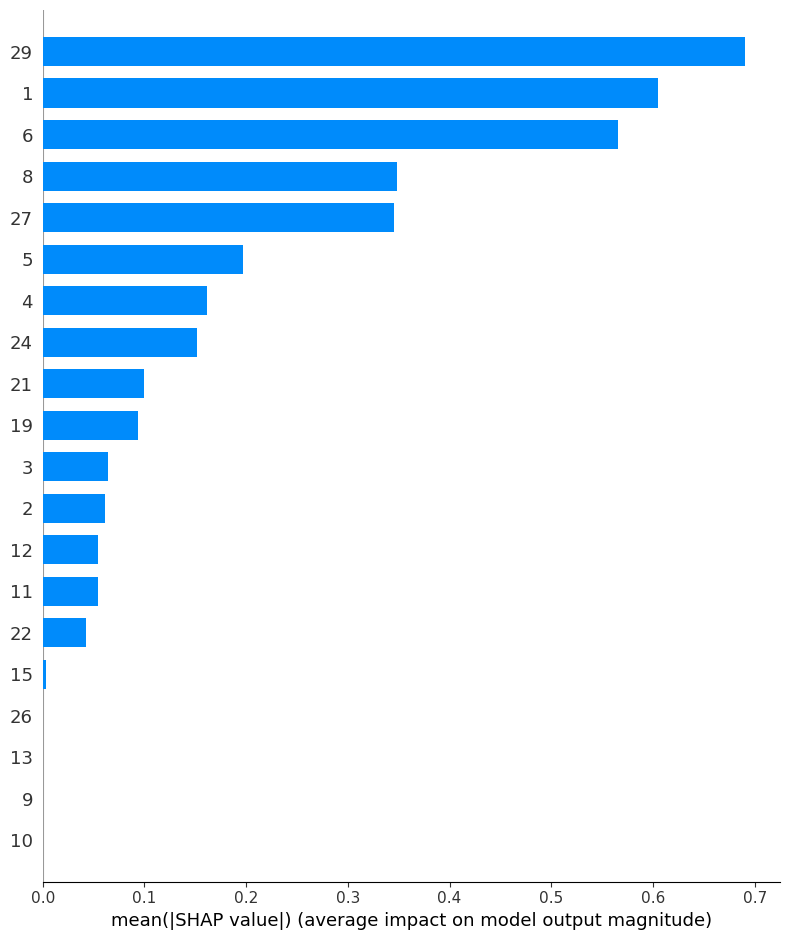

In [111]:
# Summary plot of feature importance using SHAP
shap.summary_plot(shap_values, X_test.values, plot_type="bar",class_names= class_names, feature_names = X_test.columns)


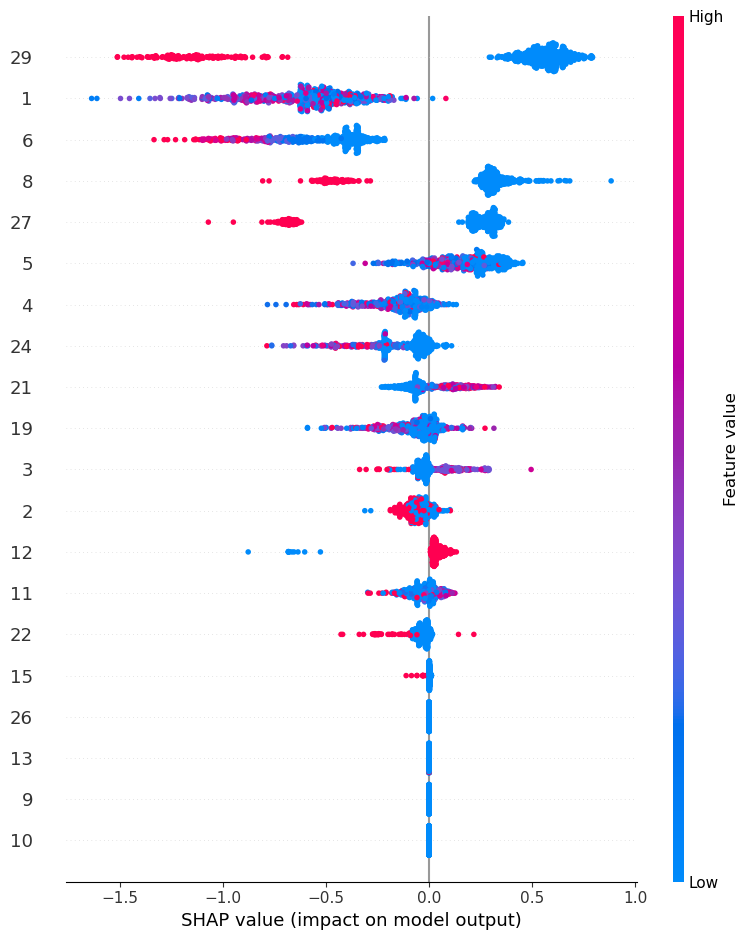

In [112]:
shap.summary_plot(shap_values, X_test.values, feature_names = X_test.columns)


In [113]:
xgb_pur_df = X_test.reset_index()
xgb_prediction = pd.DataFrame(xgb_prediction)
xgb_pur_df = pd.concat([xgb_pur_df,xgb_prediction],axis=1)
xgb_pur_df.rename(columns={0: 'prediction'}, inplace=True)
xgb_pur_df_0 = xgb_pur_df[xgb_pur_df['prediction']==0]
xgb_pur_df_1 = xgb_pur_df[xgb_pur_df['prediction']==1]

# XGBoost (Activate)

In [114]:
ids_to_remove = ['12','15','29'] 
export_piv2_2 = export_piv2.drop(columns=ids_to_remove)

In [115]:
# Modify the dependent variable as per your requirements
X, y = export_piv2_2.drop(['condition_purchase', 'condition_activation', 'condition_both'], axis=1), export_piv2_2[['condition_activation']]

# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

# Construct dmatrix for train model
dtrain_clf = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Train a model, modify the objective method as per your requirements
xgb_classifier = xgb.XGBClassifier(n_estimators=100, objective='binary:hinge', tree_method='hist', eta=0.1, max_depth=10, enable_categorical=True)
xgb_classifier.fit(X_train, y_train)

# make predictions for test data
y_pred = xgb_classifier.predict(X_test)
xgb_prediction = [round(value) for value in y_pred]

# Accuracy rate, modify the dependent variable as per your requirements
print(f"Accuracy rate: {sum(xgb_prediction == y_test['condition_activation'])/len(xgb_prediction)}")

# Sample numeric vector
numeric_vector = xgb_prediction

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")

# Sample numeric vector, modify the objective method as per your requirements
numeric_vector = y_test['condition_activation']

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")


Accuracy rate: 0.9566666666666667
Number of Each Element:
0: 130
1: 470
Number of Each Element:
0.0: 128
1.0: 472


In [116]:
X_test

,1,2,3,4,5,6,7,8,9,10,...,18,19,20,21,22,23,24,26,27,28
account_id,,,,,,,,,,,,,,,,,,,,,
-2142802924,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
-2146607356,3.0,1.0,19.0,68.0,27.0,15.0,0.0,0.0,0.0,0.0,...,0.0,105.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-2144038025,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
-2145165488,7.0,1.0,0.0,9.0,3.0,1.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,1.0
-2144166109,6.0,1.0,1.0,5.0,2.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
-2147102575,2.0,0.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-2143530065,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
-2142600730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
# Use SHAP to explain the output of the model
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test)


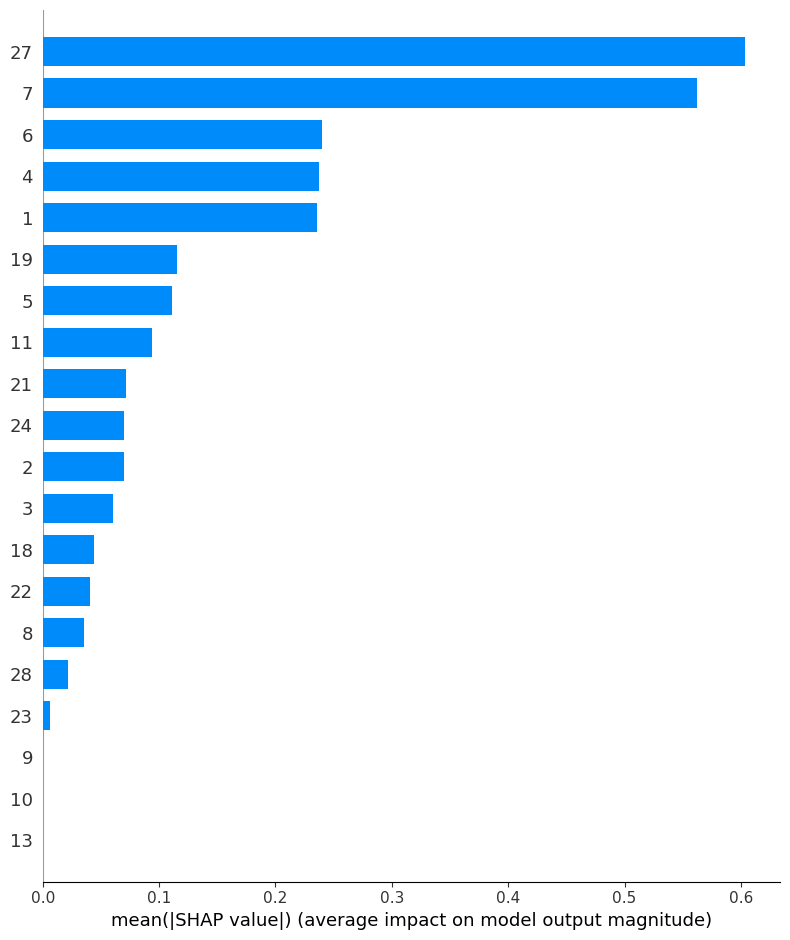

In [118]:
# Summary plot of feature importance using SHAP
shap.summary_plot(shap_values, X_test.values, plot_type="bar",class_names= class_names, feature_names = X_test.columns)


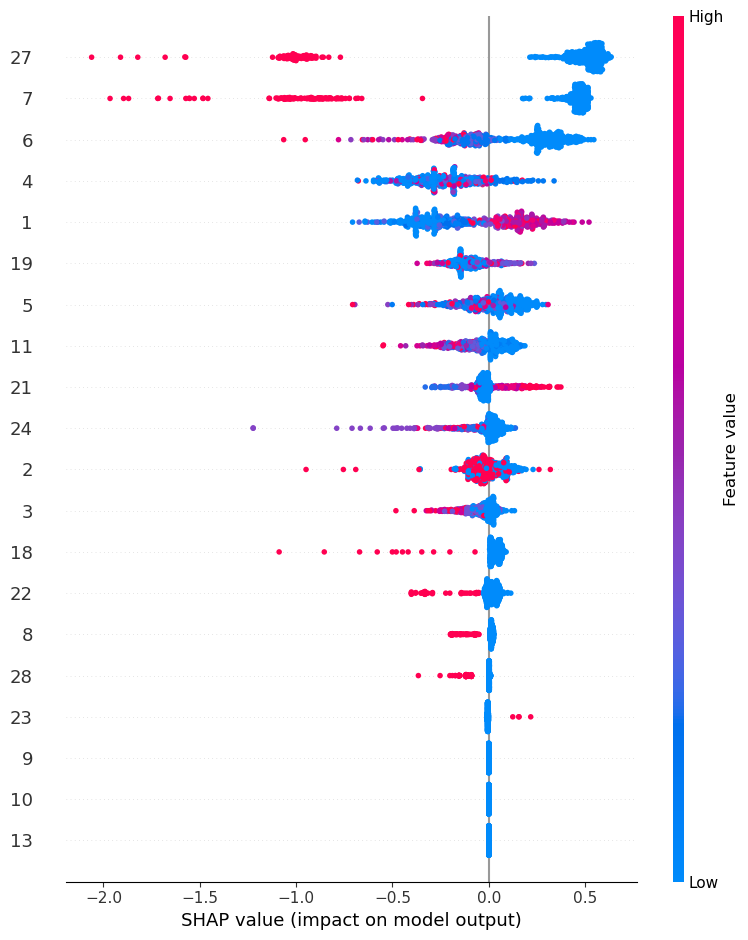

In [119]:
shap.summary_plot(shap_values, X_test.values, feature_names = X_test.columns)


In [120]:
xgb_act_df = X_test.reset_index()
xgb_prediction = pd.DataFrame(xgb_prediction)
xgb_act_df = pd.concat([xgb_act_df,xgb_prediction],axis=1)
xgb_act_df.rename(columns={0: 'prediction'}, inplace=True)
xgb_act_df_0 = xgb_act_df[xgb_act_df['prediction']==0]
xgb_act_df_1 = xgb_act_df[xgb_act_df['prediction']==1]

# XGBoost (both)

In [ ]:
ids_to_remove = ['7','18','28','12','15','29']
export_piv2_3 = export_piv2.drop(columns=ids_to_remove)


Accuracy rate: 0.9408821484409513
Number of Each Element:
2: 412339
3: 3242
0: 104556
1: 501
Number of Each Element:
2.0: 387774
3.0: 17579
0.0: 107392
1.0: 7893
Feature importance: ['27', 0.89485246]
Feature importance: ['8', 0.07567831]
Feature importance: ['6', 0.009053569]
Feature importance: ['21', 0.0051670386]
Feature importance: ['1', 0.0021805484]
Feature importance: ['2', 0.001690573]
Feature importance: ['13', 0.0014714617]
Feature importance: ['5', 0.001172884]
Feature importance: ['19', 0.0010796209]
Feature importance: ['26', 0.0010293747]
Feature importance: ['24', 0.0009164987]
Feature importance: ['3', 0.0008588008]
Feature importance: ['22', 0.0008263611]
Feature importance: ['11', 0.00080575654]
Feature importance: ['4', 0.0007336513]
Feature importance: ['16', 0.00056607206]
Feature importance: ['14', 0.000539295]
Feature importance: ['10', 0.00049515686]
Feature importance: ['20', 0.00044940857]
Feature importance: ['23', 0.00043318566]
Feature importance: ['9', 0.

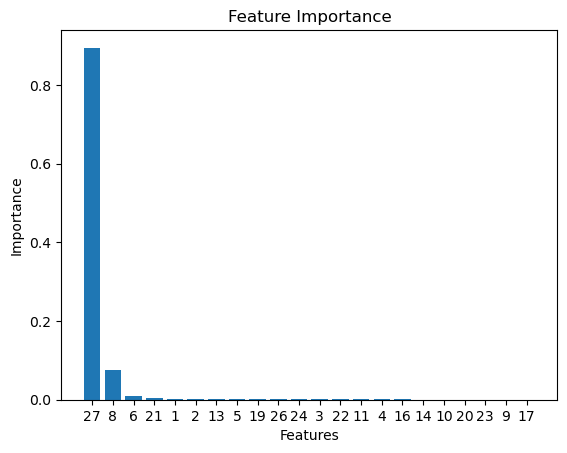

In [18]:
# Modify the dependent variable as per your requirements
X, y = export_piv2_3.drop(['condition_purchase', 'condition_activation', 'condition_both'], axis=1), export_piv2_3[['condition_both']]

# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42)

# Construct dmatrix for train model
dtrain_clf = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Train a model, modify the objective method as per your requirements
xgb_classifier = xgb.XGBClassifier(n_estimators=100, objective='multi:softprob', tree_method='hist', eta=0.1, max_depth=10, enable_categorical=True)
xgb_classifier.fit(X_train, y_train)

# make predictions for test data
y_pred = xgb_classifier.predict(X_test)
xgb_prediction = [round(value) for value in y_pred]

# Accuracy rate, modify the dependent variable as per your requirements
print(f"Accuracy rate: {sum(xgb_prediction == y_test['condition_both'])/len(xgb_prediction)}")

# Sample numeric vector
numeric_vector = xgb_prediction

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")

# Sample numeric vector, modify the objective method as per your requirements
numeric_vector = y_test['condition_both']

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")


In [23]:
# Use SHAP to explain the output of the model
explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test)


In [26]:
# Summary plot of feature importance using SHAP
shap.summary_plot(shap_values, X.values, feature_names = X.columns)


AssertionError: Summary plots need a matrix of shap_values, not a vector.

# K-means

In [31]:
export_kmean = export_piv2.drop(['condition_purchase', 'condition_activation', 'condition_both'], axis=1)
final_array = export_kmean.to_numpy()


,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,26,27,28,29
account_id,,,,,,,,,,,,,,,,,,,,,
-2147477843,4.0,1.0,0.0,9.0,5.0,2.0,1.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
-2147476504,3.0,1.0,1.0,18.0,8.0,7.0,1.0,1.0,0.0,0.0,...,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
-2147476077,0.0,1.0,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-2147475397,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
-2147473858,2.0,0.0,2.0,8.0,3.0,1.0,0.0,0.0,0.0,0.0,...,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2147469625,0.0,2.0,2.0,15.0,11.0,5.0,1.0,2.0,0.0,0.0,...,27.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
2147475185,5.0,1.0,0.0,5.0,3.0,3.0,2.0,2.0,0.0,0.0,...,0.0,0.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0
2147476319,7.0,1.0,4.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,...,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


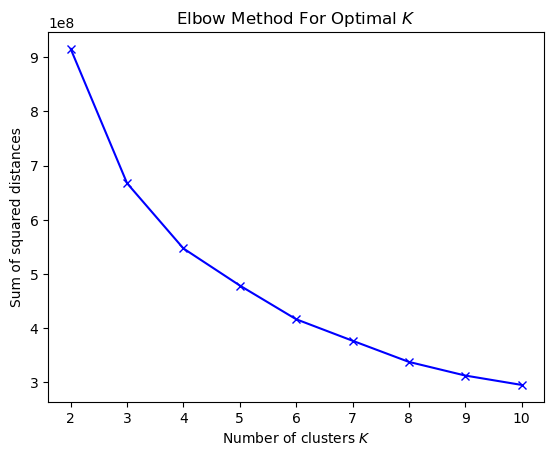

In [33]:
# Search for "optimal" number of clusters
SS_dist = []
K = range(2, 11)
for num_clusters in K:
    kmeans = KMeans(n_clusters=num_clusters, n_init=10)  # Set n_init to an integer value
    kmeans.fit(final_array)
    SS_dist.append(kmeans.inertia_)

# Plot the results
plt.plot(K, SS_dist, 'bx-')
plt.xlabel('Number of clusters $K$')
plt.ylabel('Sum of squared distances')
plt.title('Elbow Method For Optimal $K$')
plt.show()

In [40]:
# Sklearn implementation of K-Means Clustering
kmeans = KMeans(n_clusters=4, random_state=0).fit(final_array)
Partition_vec = kmeans.labels_

# Sample numeric vector, modify the objective method as per your requirements
numeric_vector = Partition_vec

# Count the occurrences of each element
element_counts = Counter(numeric_vector)

# Print the result
print("Number of Each Element:")
for element, count in element_counts.items():
    print(f"{element}: {count}")

# Add the new column called kemans_condition to the previous dataframe
kmeans_condition = pd.DataFrame(Partition_vec, columns=['kmeans_condition'])
kmeans_df = export_kmean.reset_index()
kmeans_df.columns = ['account_id','1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','26','27','28','29']
kmeans_df = pd.concat([kmeans_df,kmeans_condition['kmeans_condition']],axis=1)
kmeans_df


# Apriori

In [68]:
exclude_column = ['account_id']
export_apr = export_piv2.apply(lambda x: x if x.name == exclude_column else (x > 0).astype(int), axis=0)
remove = ['condition_purchase',	'condition_activation',	'condition_both']
export_apr = export_apr.drop(columns=remove)
export_apr.head()

,1,2,3,4,5,6,7,8,9,10,...,19,20,21,22,23,24,26,27,28,29
account_id,,,,,,,,,,,,,,,,,,,,,
-2147477843,1,1,0,1,1,1,1,1,0,0,...,0,0,0,0,0,0,0,1,1,1
-2147476504,1,1,1,1,1,1,1,1,0,0,...,1,0,0,0,0,0,0,1,1,1
-2147476077,0,1,1,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
-2147475397,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
-2147473858,1,0,1,1,1,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [42]:
kmeans_df_0 = kmeans_df[kmeans_df['kmeans_condition'] == 0]
kmeans_df_1 = kmeans_df[kmeans_df['kmeans_condition'] == 1]
kmeans_df_2 = kmeans_df[kmeans_df['kmeans_condition'] == 2]
kmeans_df_3 = kmeans_df[kmeans_df['kmeans_condition'] == 3]



kmeans_df_00 = kmeans_df_0.drop(['kmeans_condition'],axis=1)
kmeans_df_11 = kmeans_df_1.drop(['kmeans_condition'],axis=1)
kmeans_df_22 = kmeans_df_2.drop(['kmeans_condition'],axis=1)
kmeans_df_33 = kmeans_df_3.drop(['kmeans_condition'],axis=1)


ap_df_0 = pd.merge(kmeans_df_00['account_id'], export_apr, on='account_id', how='left')
ap_df_1 = pd.merge(kmeans_df_11['account_id'], export_apr, on='account_id', how='left')
ap_df_2 = pd.merge(kmeans_df_22['account_id'], export_apr, on='account_id', how='left')
ap_df_3 = pd.merge(kmeans_df_33['account_id'], export_apr, on='account_id', how='left')


ap_df_00 = ap_df_0.drop(['account_id'],axis=1)
ap_df_11 = ap_df_1.drop(['account_id'],axis=1)
ap_df_22 = ap_df_2.drop(['account_id'],axis=1)
ap_df_33 = ap_df_3.drop(['account_id'],axis=1)


In [43]:
# support - % of how often each item appears
supp_thresh = 0.05

# lift
lift_thresh = 0.8

# FILTER THRESHOLD FOR # OF ITEMS IN SET (threshold INCLUDES the given value)
n_item_thresh = 3

# sort by columns
filter_cols = ["lift"]

In [ ]:
# APRIORI ALGORITHM (group 0)

ap_set = ap(ap_df_00, min_support=supp_thresh, use_colnames=True)
rules = ap_rl(ap_set, metric = "lift", min_threshold= lift_thresh)

# vectorize length func
v_len = np.vectorize(len)

# use it for condition in rule filtering
cond_0h = v_len(rules.antecedents.values) >= n_item_thresh
cond_0t = v_len(rules.consequents.values) >= n_item_thresh

# filter rules 
rules[cond_0h].sort_values(by = filter_cols, ascending = False).head(10)
rules[cond_0t].sort_values(by = filter_cols, ascending = False).head(10)

/opt/anaconda3/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [ ]:
# APRIORI ALGORITHM (group 1)

ap_set = ap(ap_df_11, min_support=supp_thresh, use_colnames=True)
rules = ap_rl(ap_set, metric = "lift", min_threshold= lift_thresh)

# vectorize length func
v_len = np.vectorize(len)

# use it for condition in rule filtering
cond_1h = v_len(rules.antecedents.values) >= n_item_thresh
cond_1t = v_len(rules.consequents.values) >= n_item_thresh

# filter rules 
rules[cond_1h].sort_values(by = filter_cols, ascending = False).head(10)
rules[cond_1t].sort_values(by = filter_cols, ascending = False).head(10)

In [82]:
# APRIORI ALGORITHM (group 2)

ap_set = ap(ap_df_22, min_support=supp_thresh, use_colnames=True)
rules = ap_rl(ap_set, metric = "lift", min_threshold= lift_thresh)

# vectorize length func
v_len = np.vectorize(len)

# use it for condition in rule filtering
cond_2h = v_len(rules.antecedents.values) >= n_item_thresh
cond_2t = v_len(rules.consequents.values) >= n_item_thresh

# filter rules 
rules[cond_2h].sort_values(by = filter_cols, ascending = False).head(10)
rules[cond_2t].sort_values(by = filter_cols, ascending = False).head(10)

/opt/anaconda3/lib/python3.11/site-packages/mlxtend/frequent_patterns/fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
29585,"(6, 27, 2, 3, 5)","(19, 8, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
38657,"(6, 4, 27, 2, 3)","(19, 8, 1, 5)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
38634,"(6, 4, 27, 2, 3, 5)","(19, 8, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
29597,"(27, 2, 6, 3)","(19, 8, 1, 5)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
29077,"(6, 4, 27, 2, 3)","(19, 8, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
29090,"(27, 2, 6, 3)","(8, 19, 4, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
38679,"(27, 2, 6, 3)","(1, 19, 4, 8, 5)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
38660,"(6, 27, 2, 3, 5)","(8, 19, 4, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
17727,"(27, 2, 6, 3)","(19, 8, 1)",0.106501,0.222339,0.094713,0.889315,3.999817,0.071034,7.025898,0.839384
39464,"(6, 3, 4, 27, 2, 11)","(19, 8, 1)",0.106326,0.222339,0.094538,0.889133,3.998997,0.070897,7.014349,0.839162
